# ANGLE 2: Phân Tích Hiệu Quả Chương Trình Khuyến Mãi 
 Mục tiêu: Xác định promo nào đang gây lỗ và đề xuất giải pháp

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị đẹp
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})

# Màu sắc thống nhất
PROFIT_COLOR = '#2ecc71'   # xanh - có lãi
LOSS_COLOR   = '#e74c3c'   # đỏ - lỗ
NEUTRAL_COLOR= '#3498db'   # xanh dương - trung tính
WARN_COLOR   = '#f39c12'   # cam - cảnh báo

print("="*60)
print(" PHÂN TÍCH: KHUYẾN MÃI ĐANG LÀM DOANH NGHIỆP BÁN LỖ?")
print("="*60)

 PHÂN TÍCH: KHUYẾN MÃI ĐANG LÀM DOANH NGHIỆP BÁN LỖ?


## I.  Tổng quan

In [13]:
# Đọc file
order_items = pd.read_csv('order_items.csv', dtype={'promo_id': str, 'promo_id_2': str})
products    = pd.read_csv('products.csv')
promotions  = pd.read_csv('promotions.csv')
orders      = pd.read_csv('orders.csv', parse_dates=['order_date'])
customers   = pd.read_csv('customers.csv')

# Danh sách mã Urban Blowout
URBAN_IDS = ['PROMO-0005','PROMO-0015','PROMO-0025','PROMO-0035','PROMO-0045']

# Gộp dữ liệu : nối order_items với products -> nối thêm với orders
df = order_items.merge(products[['product_id','price','cogs']], on='product_id')
df = df.merge(orders[['order_id','order_date','customer_id']], on='order_id')

# Thêm các cột cần thiết
df['year']      = df['order_date'].dt.year
df['has_promo'] = df['promo_id'].notna() #đánh dấu có discount hay ko
df['is_urban']  = df['promo_id'].isin(URBAN_IDS) # đánh dấu dòng nào có promotion là "Urban Blowout"

# Tính toán lợi nhuận
df['revenue']    = df['quantity'] * df['unit_price']  #Doanh thu: tổng số tiền khách trả (unit_price: giá của món hành sau giảm)
df['cogs_total'] = df['quantity'] * df['cogs']        #Tổng vốn (total cost)
df['profit']     = df['revenue'] - df['cogs_total'] - df['discount_amount']  # Lợi nhuận
df['margin']     = df['profit'] / df['revenue'].replace(0, np.nan)       # Biên lợi nhuận: tỷ lệ lời trên mỗi đồng doanh thu

# Tỷ lệ giá bán thực tế / giá gốc (PHÁT HIỆN QUAN TRỌNG)
df['price_ratio'] = df['unit_price'] / df['price'] #để xem khách hàng đang đc giảm bao nhiêu %

print(f"\n✅ Đọc dữ liệu xong!")
print(f"   Tổng số dòng đơn hàng: {len(df):,}")
print(f"   Có promo: {df['has_promo'].sum():,} ({df['has_promo'].mean()*100:.1f}%)")


✅ Đọc dữ liệu xong!
   Tổng số dòng đơn hàng: 714,669
   Có promo: 276,316 (38.7%)


In [14]:
# ============================================================
# GIẢI THÍCH CÁC BIẾN SỬ DỤNG TRONG PHÂN TÍCH
# ============================================================

print("\n" + "="*70)
print("GIẢI THÍCH CÁC BIẾN TRONG CODE")
print("="*70)

explanation = """
┌─────────────────────────────────────────────────────────────────────────────┐
│ BIẾN                    │ Ý NGHĨA                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Từ file order_items.csv**                                               │
│ unit_price              │ Giá bán SAU khuyến mãi của 1 sản phẩm            │
│ quantity                │ Số lượng sản phẩm trong dòng order               │
│ discount_amount         │ Tổng số tiền được giảm cho DÒNG sản phẩm         │
│ promo_id                │ Mã khuyến mãi chính (FK → promotions)            │
│ promo_id_2              │ Mã khuyến mãi thứ hai (nếu có stacked promo)     │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Từ file products.csv**                                                  │
│ price                   │ Giá niêm yết GỐC (trước khuyến mãi)              │
│ cogs                    │ Giá vốn của 1 sản phẩm (Cost of Goods Sold)      │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Biến tự tạo (derived)**                                                 │
│ revenue                 │ Doanh thu = quantity × unit_price                │
│ cogs_total              │ Tổng giá vốn = quantity × cogs                   │
│ profit                  │ Lợi nhuận = revenue - cogs_total - discount_amount│
│ margin                  │ Biên lợi nhuận = profit / revenue (%)           │
│ price_ratio             │ Tỷ lệ giá bán/giá gốc = unit_price / price      │
│ margin_goc              │ Biên lợi nhuận gốc = (price - cogs) / price     │
│ has_promo               │ Có promo? (promo_id không null)                  │
│ is_urban                │ Có phải Urban Blowout không?                     │
│ year                    │ Năm lấy từ order_date                            │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Biến dùng trong phân tích khách hàng**                                  │
│ avg_urban               │ Số đơn trung bình của khách dùng Urban           │
│ avg_non_promo           │ Số đơn trung bình của khách không dùng promo     │
│ lift                    │ Mức cải thiện retention = (avg_urban - avg_non_promo)/avg_non_promo │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Biến dùng trong dự báo (Chart 4)**                                       │
│ profit_A                │ Lợi nhuận nếu giữ fixed 50                       │
│ profit_B                │ Lợi nhuận nếu đổi sang percentage 10%           │
│ cum_A / cum_B           │ Lợi nhuận tích lũy theo năm                      │
│ gap                     │ Chênh lệch lợi nhuận giữa 2 kịch bản             │
└─────────────────────────────────────────────────────────────────────────────┘

 CÔNG THỨC TÍNH DISCOUNT (theo đề thi):
   • Fixed (Urban Blowout): discount_amount = quantity × 50
   • Percentage: discount_amount = quantity × unit_price × (discount_value/100)

 LƯU Ý:
   unit_price đã là giá SAU khuyến mãi. KHÔNG cộng discount_amount vào unit_price.
   profit = revenue - cogs_total - discount_amount (theo đúng cấu trúc đề thi)
"""

print(explanation)


GIẢI THÍCH CÁC BIẾN TRONG CODE

┌─────────────────────────────────────────────────────────────────────────────┐
│ BIẾN                    │ Ý NGHĨA                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Từ file order_items.csv**                                               │
│ unit_price              │ Giá bán SAU khuyến mãi của 1 sản phẩm            │
│ quantity                │ Số lượng sản phẩm trong dòng order               │
│ discount_amount         │ Tổng số tiền được giảm cho DÒNG sản phẩm         │
│ promo_id                │ Mã khuyến mãi chính (FK → promotions)            │
│ promo_id_2              │ Mã khuyến mãi thứ hai (nếu có stacked promo)     │
├─────────────────────────────────────────────────────────────────────────────┤
│ **Từ file products.csv**                                                  │
│ price                   │ Giá niêm yết GỐC (trước khuyến mãi)              │
│ cogs            

## II. Promotion có phải là vấn đề ? 

### 1 - PROMO VS NON-PROMO (DESCRIPTIVE)
**Mục tiêu**: Xác định xem promo có đang là vấn đề hay ko

In [15]:
# Tính tổng hợp: nhóm để so sánh
summary = df.groupby('has_promo').agg({ #nhóm theo cột has_promo -> có hay ko có promotion
    'margin': 'mean', #trung bình 1 đơn hàng trong nhóm promo/ko promo thì lời đc bao nhiêu %
    'profit': 'sum'
}).reset_index()

summary['label'] = summary['has_promo'].map({False: 'Không promo', True: 'Có promo'})
summary

,has_promo,margin,profit,label
0,False,0.208325,2.195015e+09,Không promo
1,True,-0.127522,-6.775966e+08,Có promo


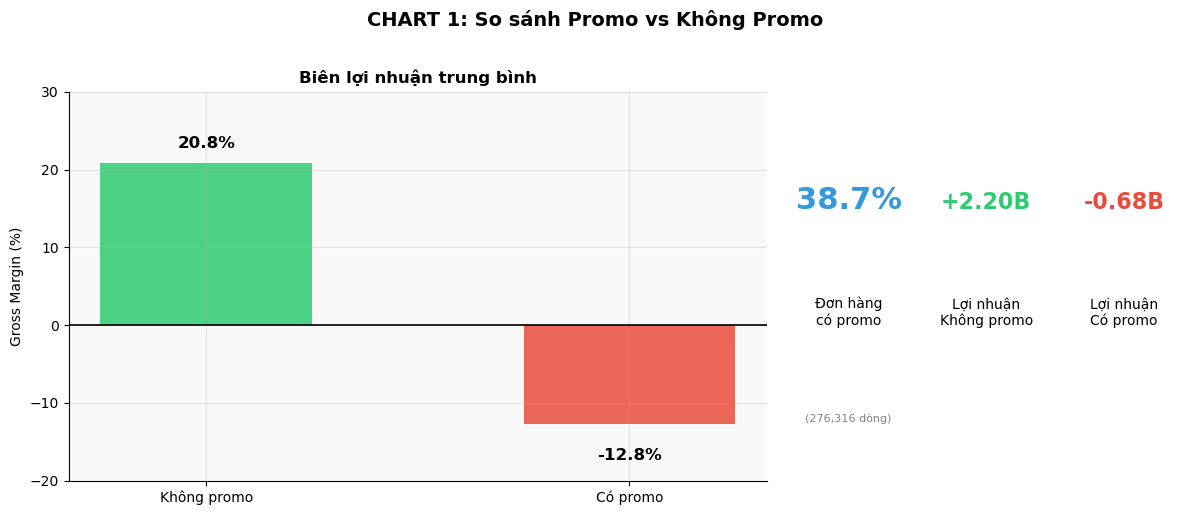


 KẾT LUẬN CHART 1

   -  Không promo:
      • Biên lợi nhuận: +20.8%
      • Lợi nhuận: +2.20 tỷ VND

   - Có promo:
      • Biên lợi nhuận: -12.8%
      • Lợi nhuận: -0.68 tỷ VND (lỗ 0.68 tỷ)

   - 38.7% số dòng đơn hàng có promo.
   
   → Kết luận: Đơn hàng có promo đang lỗ, trong khi không promo có lãi tốt.
     Cần xác định promo nào là thủ phạm chính.



In [16]:
# ============================================================
# CHART 1 — DESCRIPTIVE: PROMO VS KHÔNG PROMO
# ============================================================



# Lấy các giá trị cần dùng: chỉ là lấy để vẽ graph 
margin_no_promo = summary[~summary['has_promo']]['margin'].values[0] * 100 #biên lợi nhuận của ko có promo
margin_with_promo = summary[summary['has_promo']]['margin'].values[0] * 100 #biên lợi nhiuanaj của có lọi nhuận
profit_no_promo = summary[~summary['has_promo']]['profit'].values[0] / 1e9
profit_with_promo = summary[summary['has_promo']]['profit'].values[0] / 1e9
pct_promo = df['has_promo'].mean() * 100

# Tạo figure với 2 cột: biểu đồ (60%) và card (40%)
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 5, width_ratios=[3, 3, 1, 1, 1])

# === Cột 1-2: Biểu đồ margin ===
ax1 = fig.add_subplot(gs[0, 0:2])#thiets lập khung 
colors = [PROFIT_COLOR if margin_no_promo > 0 else LOSS_COLOR, #margin > 0 (có lãi) -> màu xanh 
          PROFIT_COLOR if margin_with_promo > 0 else LOSS_COLOR] #ngược lại thì màu đỏ
#VẼ BAR GRAPH cho 2 cột  ko promo, có promo
bars = ax1.bar(summary['label'], [margin_no_promo, margin_with_promo], 
               color=colors, width=0.5, alpha=0.85)  
ax1.axhline(0, color='black', linewidth=1.2)
ax1.set_ylabel('Gross Margin (%)')
ax1.set_title('Biên lợi nhuận trung bình', fontweight='bold')
ax1.set_ylim(-20, 30)

#ghi số lên đầu cột
for bar, val in zip(bars, [margin_no_promo, margin_with_promo]):
    offset = 1.5 if val > 0 else -3
    va = 'bottom' if val > 0 else 'top'
    ax1.text(bar.get_x() + bar.get_width()/2, val + offset, f'{val:.1f}%', 
             ha='center', va=va, fontweight='bold', fontsize=12)

# === Cột 3-5: KPI Cards === 
#cái này có thể xài cho đầu Dashboard (kết quả đã nằm ở trên hết r, h trình bày ra thôi)

# Card 1: Tỷ lệ đơn có promo
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
ax2.text(0.5, 0.7, f'{pct_promo:.1f}%', ha='center', fontsize=22, fontweight='bold', color=NEUTRAL_COLOR)
ax2.text(0.5, 0.4, 'Đơn hàng\ncó promo', ha='center', fontsize=10)
ax2.text(0.5, 0.15, f'({df["has_promo"].sum():,} dòng)', ha='center', fontsize=8, color='gray')

# Card 2: Lợi nhuận không promo
ax3 = fig.add_subplot(gs[0, 3])
ax3.axis('off')
color_no_promo = PROFIT_COLOR if profit_no_promo > 0 else LOSS_COLOR
ax3.text(0.5, 0.7, f'+{profit_no_promo:.2f}B', ha='center', fontsize=16, fontweight='bold', color=color_no_promo)
ax3.text(0.5, 0.4, 'Lợi nhuận\nKhông promo', ha='center', fontsize=10)

# Card 3: Lợi nhuận có promo
ax4 = fig.add_subplot(gs[0, 4])
ax4.axis('off')
color_with_promo = PROFIT_COLOR if profit_with_promo > 0 else LOSS_COLOR
sign = '+' if profit_with_promo > 0 else ''
ax4.text(0.5, 0.7, f'{sign}{profit_with_promo:.2f}B', ha='center', fontsize=16, fontweight='bold', color=color_with_promo)
ax4.text(0.5, 0.4, 'Lợi nhuận\nCó promo', ha='center', fontsize=10)

fig.suptitle('CHART 1: So sánh Promo vs Không Promo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Kết luận
print("\n" + "="*60)
print(" KẾT LUẬN CHART 1")
print("="*60)
print(f"""
   -  Không promo:
      • Biên lợi nhuận: +{margin_no_promo:.1f}%
      • Lợi nhuận: +{profit_no_promo:.2f} tỷ VND

   - Có promo:
      • Biên lợi nhuận: {margin_with_promo:.1f}%
      • Lợi nhuận: {profit_with_promo:.2f} tỷ VND (lỗ {abs(profit_with_promo):.2f} tỷ)

   - {pct_promo:.1f}% số dòng đơn hàng có promo.
   
   → Kết luận: Đơn hàng có promo đang lỗ, trong khi không promo có lãi tốt.
     Cần xác định promo nào là thủ phạm chính.
""")

### 2 -  Những promotions nào đang lỗ nặng: Descriptive

In [17]:
# Tính lợi nhuận theo từng promo
#giữ lại những dòng có promo, group theo promo_id
promo_perf = df[df['has_promo']].groupby('promo_id').agg({
    'revenue': 'sum', #tổng số tiền khách trả cho mã
    'profit': 'sum', #tổng lời/lỗ mà mã đó mang lại
    'order_id': 'nunique' #đếm xem có bao nhiêu đơn hàng duy nhất đã sử dụng mã
}).reset_index()
#tính phần trăm biên lợi nhuận cho từng mã
promo_perf['margin'] = promo_perf['profit'] / promo_perf['revenue'] * 100

# Thêm tên promo
promo_perf = promo_perf.merge(promotions[['promo_id', 'promo_name', 'promo_type']], on='promo_id')
promo_perf = promo_perf.sort_values('margin').head(5) #sắp xếp margin từ thấp tới cao-> 5 đứa đầu bảng  = 5 đứa margin thấp nhất
promo_perf



,promo_id,revenue,profit,order_id,margin,promo_name,promo_type
44,PROMO-0045,53698004.74,-3.606065e+07,2413,-67.154542,Urban Blowout 2021,fixed
14,PROMO-0015,84923489.85,-5.320122e+07,5012,-62.646060,Urban Blowout 2015,fixed
4,PROMO-0005,82021991.91,-5.127487e+07,4831,-62.513564,Urban Blowout 2013,fixed
24,PROMO-0025,93323384.69,-5.754747e+07,5323,-61.664574,Urban Blowout 2017,fixed
34,PROMO-0035,62506870.11,-3.717308e+07,3162,-59.470397,Urban Blowout 2019,fixed


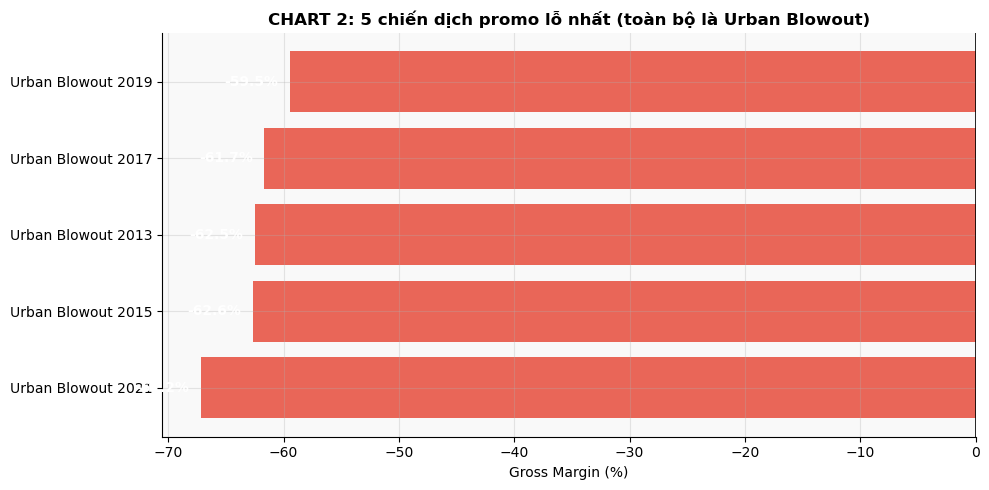


 KẾT LUẬN CHART 2
 5 promo lỗ nhất toàn bộ là URBAN BLOWOUT
   → Cần tập trung phân tích chiến dịch này.



In [19]:
# ============================================================
# CHART 2 — Descriptive: TOP 5 PROMO LỖ NHẤT
# ============================================================
# Vẽ biểu đồ 
fig, ax = plt.subplots(figsize=(10, 5))
colors = [LOSS_COLOR for _ in range(len(promo_perf))]  # 5 cái đều là Urban → đỏ hết
#vẽ horizontal bar
ax.barh(promo_perf['promo_name'], promo_perf['margin'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Gross Margin (%)')
ax.set_title('CHART 2: 5 chiến dịch promo lỗ nhất (toàn bộ là Urban Blowout)', fontweight='bold')

# Thêm số liệu trên cột
for bar, val in zip(ax.patches, promo_perf['margin']):
    ax.text(val - 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            ha='right', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Kết luận
print("\n" + "="*60)
print(" KẾT LUẬN CHART 2")
print(""" 5 promo lỗ nhất toàn bộ là URBAN BLOWOUT
   → Cần tập trung phân tích chiến dịch này.
""")

## III. Tại sao Urban Blowout lỗ ?

### 3- Urban Blowout có phải là nguyên nhân chính không?
Mục tiêu: Giải thích nguyên nhân gốc rễ.

In [7]:
# 1. Tách riêng các đơn hàng Urban
urban = df[df['is_urban']].copy() 

# 2. Tính mức giảm giá trung bình (50% nghĩa là giảm một nửa giá)
ratio_urban = urban['price_ratio'].mean() 

# 3. Đếm số loại sản phẩm THỰC TẾ đã bán trong Urban
n_products = urban['product_id'].nunique() 

# 4. CHUẨN BỊ BẢNG SOI: Lấy thông tin gốc của 636 món này
urban_products_check = products[products['product_id'].isin(urban['product_id'].unique())].copy()

# 5. TÍNH TOÁN: Lợi nhuận gốc (số tiền và %)
urban_products_check['lai_goc_tien'] = urban_products_check['price'] - urban_products_check['cogs'] #Số tiền lời thu về nếu bán đúng giá.
urban_products_check['margin_goc'] = (urban_products_check['lai_goc_tien']) / urban_products_check['price'] * 100 #biên lợi nhuận gốc

# 6. ĐẾM VÙNG NGUY HIỂM: Trong 636 món đó, món nào lời ít hơn 50đ?
n_products_below_50 = urban_products_check[urban_products_check['lai_goc_tien'] < 50]['product_id'].count() #đếm mon có lãi gốc < 50đ

# 7. TỶ LỆ CHẾT CHÓC: Bao nhiêu % món có margin gốc không tới 50%?
pct_below_50 = (urban_products_check['margin_goc'] < 50).mean() * 100  #tỷ lệ món có biên lợi nhuận gốc < 50%

# --- XUẤT BẢN SỐ LIỆU ---
print(f"Tỷ lệ giá khách trả: {ratio_urban*100:.1f}%")
print(f"Số sản phẩm chạy Urban: {n_products} món")
print(f"Số món có lãi gốc < 50đ: {n_products_below_50} món")
print(f"Tỷ lệ món có Margin gốc < 50%: {pct_below_50:.1f}%")

Tỷ lệ giá khách trả: 50.0%
Số sản phẩm chạy Urban: 636 món
Số món có lãi gốc < 50đ: 0 món
Tỷ lệ món có Margin gốc < 50%: 100.0%


LỖ CẤU TRÚC, KHÔNG PHẢI DO DISCOUNT 50đ!

Lý do:
1. discount 50đ chỉ là 1-5% giá sản phẩm (vì sản phẩm Urban giá ~1.000-5.000đ)
2. NHƯNG Urban bán với giá = 50% giá gốc → giảm 50%, không phải giảm 50đ!
3. Trong khi margin gốc của sản phẩm < 50% (nhiều món margin rất thấp)

Discount 50đ chỉ là "phần phụ" — vì lãi gốc của tất cả sản phẩm đều > 50đ, nên discount 50đ không đáng kể. Vấn đề thực sự là chính sách giảm giá 50% trên sản phẩm có biên lợi nhuận quá mỏng.

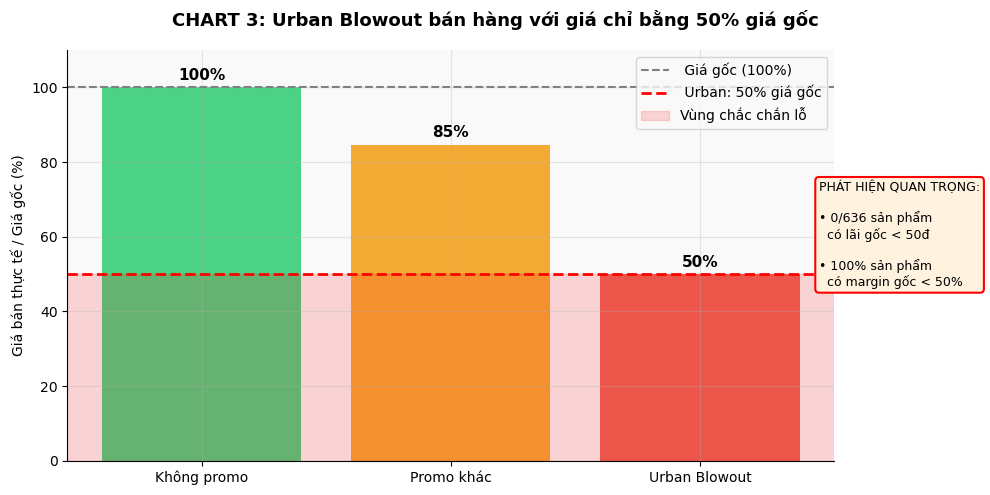


 KẾT LUẬN CHART 3 (DIAGNOSTIC)

    Urban bán với giá: 50% giá gốc
    100% sản phẩm có margin gốc < 50%
    0/636 sản phẩm có lãi gốc < 50đ

   → KẾT LUẬN: Lỗ cấu trúc, KHÔNG phải do discount 50đ!



In [23]:
# ============================================================
# CHART 3 — TẠI SAO URBAN BLOWOUT LỖ? (DIAGNOSTIC)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('CHART 3: Urban Blowout bán hàng với giá chỉ bằng 50% giá gốc', 
             fontsize=13, fontweight='bold')

# Vẽ biểu đồ cột như cũ
labels = ['Không promo', 'Promo khác', 'Urban Blowout']
values = [
    df[~df['has_promo']]['price_ratio'].mean(),
    df[df['has_promo'] & ~df['is_urban']]['price_ratio'].mean(),
    ratio_urban
]

colors_bar = [PROFIT_COLOR, WARN_COLOR, LOSS_COLOR]
bars = ax.bar(labels, [v*100 for v in values], color=colors_bar, alpha=0.85)

ax.axhline(100, color='gray', linestyle='--', label=' Giá gốc (100%)')
ax.axhline(50, color='red', linestyle='--', linewidth=2, label=' Urban: 50% giá gốc')

# TÔ MÀU VÙNG LỖ (0-50%)
ax.axhspan(0, 50, alpha=0.15, color='red', label='Vùng chắc chắn lỗ')

ax.set_ylabel('Giá bán thực tế / Giá gốc (%)')
ax.set_ylim(0, 110)
ax.legend(loc='upper right')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 2, f'{val*100:.0f}%', 
            ha='center', fontweight='bold', fontsize=11)

# ==========  THÊM CALLBOX HIỂN THỊ SỐ LIỆU QUAN TRỌNG ==========
# Khung chú thích bên phải biểu đồ
textstr = f'PHÁT HIỆN QUAN TRỌNG:\n\n• {n_products_below_50}/{n_products} sản phẩm\n  có lãi gốc < 50đ\n\n• {pct_below_50:.0f}% sản phẩm\n  có margin gốc < 50%'

ax.text(0.98, 0.55, textstr, transform=ax.transAxes,
        fontsize=9, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='#FFF3E0', edgecolor='red', linewidth=1.5))

plt.tight_layout()
plt.show()

# In kết luận
print("\n" + "="*60)
print(" KẾT LUẬN CHART 3 (DIAGNOSTIC)")
print("="*60)
print(f"""
    Urban bán với giá: {ratio_urban*100:.0f}% giá gốc
    {pct_below_50:.0f}% sản phẩm có margin gốc < 50%
    0/636 sản phẩm có lãi gốc < 50đ

   → KẾT LUẬN: Lỗ cấu trúc, KHÔNG phải do discount 50đ!
""")

### 4 - Phân tích khách hàng của Urban Blowout
mục tiêu: kiểm tra xem khách hàng dùng Urban có trung thành ko để xem có nên cắt urban ko


In [24]:
# 1. Lấy danh sách khách hàng dùng Urban Blowout
urban_orders = orders[orders['order_id'].isin(urban['order_id'].unique())]
urban_customers = urban_orders['customer_id'].unique()

# 2. Lấy danh sách khách hàng không dùng bất kỳ promo nào
non_promo_orders = orders[~orders['order_id'].isin(df[df['has_promo']]['order_id'].unique())]
non_promo_customers = non_promo_orders['customer_id'].unique()

# 3. Số đơn trung bình mỗi khách
avg_urban = orders[orders['customer_id'].isin(urban_customers)].groupby('customer_id').size().mean()
avg_non_promo = orders[orders['customer_id'].isin(non_promo_customers)].groupby('customer_id').size().mean()
lift = (avg_urban - avg_non_promo) / avg_non_promo * 100

# 4. Chất lượng khách Urban: tỷ lệ khách Urban có mua hàng không promo
non_promo_urban_orders = orders[
    (orders['customer_id'].isin(urban_customers)) & 
    (~orders['order_id'].isin(df[df['has_promo']]['order_id']))
]
non_promo_urban_customers = non_promo_urban_orders['customer_id'].nunique()
pct_quality = non_promo_urban_customers / len(urban_customers) * 100

# 5. Tỷ lệ đơn không promo trên tổng số đơn của khách Urban
urban_customers_orders = orders[orders['customer_id'].isin(urban_customers)]
total_orders_urban = len(urban_customers_orders)
non_promo_orders_urban = len(non_promo_urban_orders)
pct_orders = non_promo_orders_urban / total_orders_urban * 100

# In kiểm tra (tùy chọn)
print(f"Khách Urban: {len(urban_customers)} người, trung bình {avg_urban:.2f} đơn")
print(f"Khách không promo: {len(non_promo_customers)} người, trung bình {avg_non_promo:.2f} đơn")
print(f"Lift: +{lift:.1f}%")
print(f"Khách Urban mua cả không promo: {pct_quality:.1f}%")
print(f"Tỷ lệ đơn không promo của khách Urban: {pct_orders:.1f}%")

Khách Urban: 16495 người, trung bình 14.78 đơn
Khách không promo: 78945 người, trung bình 8.00 đơn
Lift: +84.7%
Khách Urban mua cả không promo: 92.6%
Tỷ lệ đơn không promo của khách Urban: 58.2%


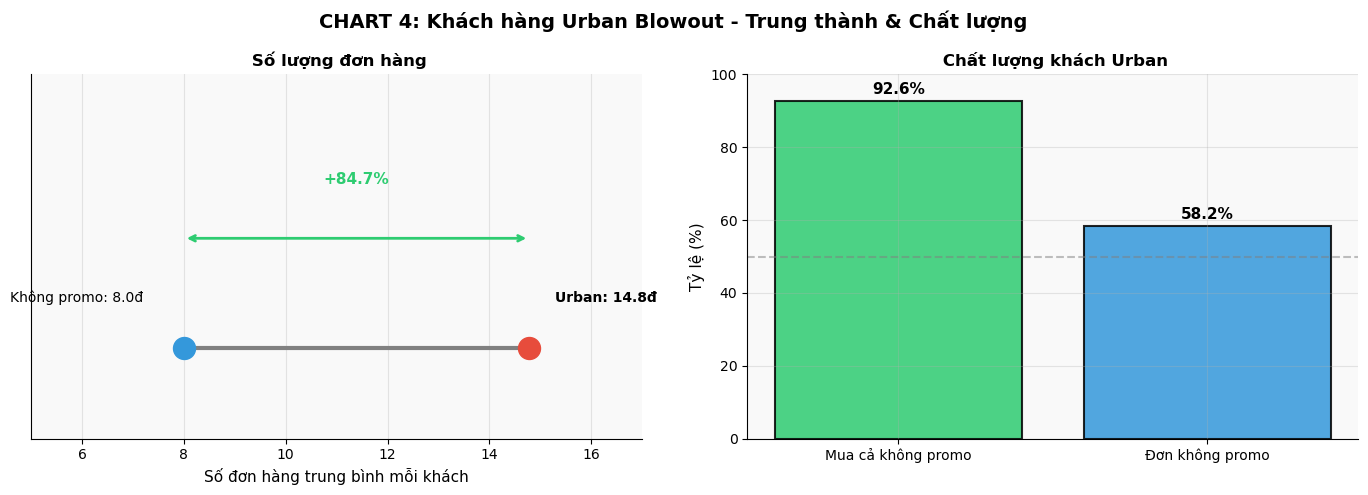


 KẾT LUẬN: Khách Urban mua nhiều hơn 84.7%, 92.6% mua cả không promo → KHÔNG NGHIỆN GIẢM GIÁ → Có thể tăng giá!


In [29]:
# ============================================================
# CHART 4 — RETENTION (FIX LỖI CẮT)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # Tăng width lên 14
fig.subplots_adjust(top=0.85)  # Tạo khoảng trống cho title

fig.suptitle('CHART 4: Khách hàng Urban Blowout - Trung thành & Chất lượng', 
             fontweight='bold', fontsize=14, y=0.98)

# Dumbbell chart
ax1.hlines(0, avg_non_promo, avg_urban, color='gray', lw=3)
ax1.scatter(avg_non_promo, 0, s=250, color=NEUTRAL_COLOR, zorder=5)
ax1.scatter(avg_urban, 0, s=250, color=LOSS_COLOR, zorder=5)

# Thêm label trực tiếp gần điểm
ax1.text(avg_non_promo - 0.8, 0.05, f'Không promo: {avg_non_promo:.1f}đ', 
         ha='right', fontsize=10)
ax1.text(avg_urban + 0.5, 0.05, f'Urban: {avg_urban:.1f}đ', 
         ha='left', fontsize=10, fontweight='bold')

# Mũi tên chênh lệch
ax1.annotate('', xy=(avg_urban, 0.12), xytext=(avg_non_promo, 0.12),
             arrowprops=dict(arrowstyle='<->', color=PROFIT_COLOR, lw=2))
ax1.text((avg_urban+avg_non_promo)/2, 0.18, f'+{lift:.1f}%', 
         ha='center', fontweight='bold', fontsize=11, color=PROFIT_COLOR)

ax1.set_xlim(5, 17)
ax1.set_ylim(-0.1, 0.3)
ax1.set_yticks([])
ax1.set_xlabel('Số đơn hàng trung bình mỗi khách', fontsize=11)
ax1.set_title(' Số lượng đơn hàng', fontweight='bold', fontsize=12)

# Bar chart
bars = ax2.bar(['Mua cả không promo', 'Đơn không promo'], 
               [pct_quality, pct_orders], 
               color=[PROFIT_COLOR, NEUTRAL_COLOR], 
               alpha=0.85, edgecolor='black', linewidth=1.5)

ax2.set_ylim(0, 100)
ax2.set_ylabel('Tỷ lệ (%)', fontsize=11)
ax2.set_title(' Chất lượng khách Urban', fontweight='bold', fontsize=12)
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5)

for bar, val in zip(bars, [pct_quality, pct_orders]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()
print(f"\n KẾT LUẬN: Khách Urban mua nhiều hơn {lift:.1f}%, {pct_quality:.1f}% mua cả không promo → KHÔNG NGHIỆN GIẢM GIÁ → Có thể tăng giá!")


## IV. Dự báo tác động của thay đổi giá (Predictive)

## Phần 5: So sánh kịch bản – Giữ 50% vs. Tăng lên 90% giá gốc
Mục tiêu: Dự báo thiệt hại tương lai và nếu thay đổi thì lời bao nhiêu.

In [30]:
# ============================================================
# 1. Chuẩn bị dữ liệu
# ============================================================
urban = df[df['is_urban']].copy()

# Doanh thu & lợi nhuận hiện tại (giá = 50%)
urban['revenue_current'] = urban['quantity'] * urban['unit_price']
urban['cogs_total'] = urban['quantity'] * urban['cogs']
urban['profit_current'] = urban['revenue_current'] - urban['cogs_total'] - urban['discount_amount']

# Kịch bản mới (giá = 90%)
urban['price_90pct'] = urban['price'] * 0.90
urban['revenue_new'] = urban['quantity'] * urban['price_90pct']
urban['profit_new'] = urban['revenue_new'] - urban['cogs_total'] - urban['discount_amount']

# ============================================================
# 2. Gộp theo năm
# ============================================================
by_year = urban.groupby('year').agg(
    profit_current=('profit_current', 'sum'),
    profit_new=('profit_new', 'sum'),
).reset_index()

# ============================================================
# 3. Forecast (loại bỏ 2022 vì chưa full năm)
# ============================================================
by_year_full = by_year[by_year['year'] < 2022]

# Lấy trung bình 2 năm gần nhất (full data)
by_year_full = by_year_full.sort_values('year')

avg_current = by_year_full.tail(2)['profit_current'].mean()
avg_new = by_year_full.tail(2)['profit_new'].mean()

# ============================================================
# 4. Tạo dữ liệu tương lai
# ============================================================
future_years = list(range(2023, 2030))  # 2023 → 2029

future_current = [avg_current] * len(future_years)
future_new = [avg_new] * len(future_years)

# ============================================================
# 5. Gộp quá khứ + tương lai
# ============================================================
hist_years = list(by_year['year'])
all_years = hist_years + future_years

all_profit_current = list(by_year['profit_current']) + future_current
all_profit_new = list(by_year['profit_new']) + future_new

# Lợi nhuận tích lũy
cum_current = np.cumsum(all_profit_current)
cum_new = np.cumsum(all_profit_new)

n_hist = len(hist_years)



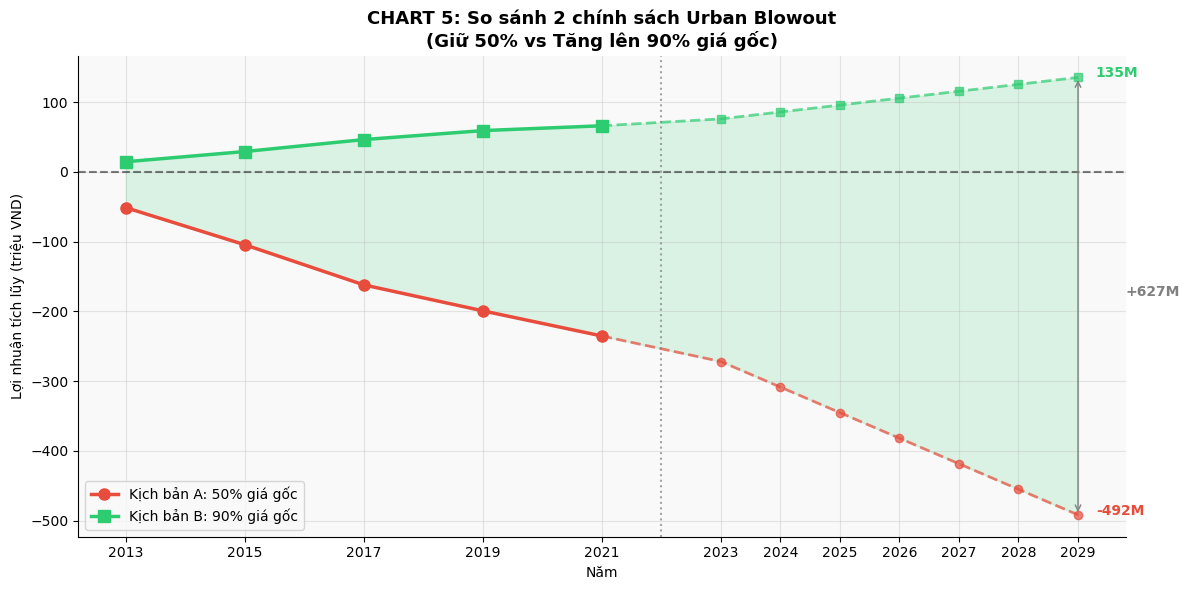


 KẾT QUẢ CHART 5 (CHÍNH SÁCH GIÁ)

[KỊCH BẢN A: 50% giá gốc]
• Lỗ tích lũy: -492 triệu VND

[KỊCH BẢN B: 90% giá gốc]
• Lãi tích lũy: 135 triệu VND

CHÊNH LỆCH: +627 triệu VND

=> Tăng giá lên 90% giúp cải thiện lợi nhuận đáng kể.



In [31]:

# ============================================================
# 6. Vẽ biểu đồ
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_title(
    'CHART 5: So sánh 2 chính sách Urban Blowout\n(Giữ 50% vs Tăng lên 90% giá gốc)',
    fontsize=13, fontweight='bold'
)

# Vùng chênh lệch
ax.fill_between(all_years, cum_current/1e6, cum_new/1e6,
                alpha=0.15, color=PROFIT_COLOR)

# Kịch bản A
ax.plot(all_years[:n_hist], cum_current[:n_hist]/1e6,
        'o-', color=LOSS_COLOR, linewidth=2.5, markersize=8,
        label='Kịch bản A: 50% giá gốc')

ax.plot(all_years[n_hist-1:], cum_current[n_hist-1:]/1e6,
        'o--', color=LOSS_COLOR, linewidth=2, alpha=0.7)

# Kịch bản B
ax.plot(all_years[:n_hist], cum_new[:n_hist]/1e6,
        's-', color=PROFIT_COLOR, linewidth=2.5, markersize=8,
        label='Kịch bản B: 90% giá gốc')

ax.plot(all_years[n_hist-1:], cum_new[n_hist-1:]/1e6,
        's--', color=PROFIT_COLOR, linewidth=2, alpha=0.7)

# Trục & đường tham chiếu
ax.axvline(2022, color='gray', linestyle=':', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)

ax.set_xlabel('Năm')
ax.set_ylabel('Lợi nhuận tích lũy (triệu VND)')
ax.set_xticks(all_years)
ax.legend(loc='lower left')

# Ghi chú điểm cuối
ax.text(2029+0.3, cum_current[-1]/1e6,
        f'{cum_current[-1]/1e6:.0f}M',
        color=LOSS_COLOR, fontweight='bold')

ax.text(2029+0.3, cum_new[-1]/1e6,
        f'{cum_new[-1]/1e6:.0f}M',
        color=PROFIT_COLOR, fontweight='bold')

# Chênh lệch
gap = (cum_new[-1] - cum_current[-1]) / 1e6

ax.annotate('', xy=(2029, cum_new[-1]/1e6),
            xytext=(2029, cum_current[-1]/1e6),
            arrowprops=dict(arrowstyle='<->', color='gray'))

ax.text(2029+0.8,
        (cum_current[-1]+cum_new[-1])/2/1e6,
        f'+{gap:.0f}M',
        color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 7. In kết quả
# ============================================================
print("\n" + "="*60)
print(" KẾT QUẢ CHART 5 (CHÍNH SÁCH GIÁ)")
print("="*60)

print(f"""
[KỊCH BẢN A: 50% giá gốc]
• Lỗ tích lũy: {cum_current[-1]/1e6:.0f} triệu VND

[KỊCH BẢN B: 90% giá gốc]
• Lãi tích lũy: {cum_new[-1]/1e6:.0f} triệu VND

CHÊNH LỆCH: +{gap:.0f} triệu VND

=> Tăng giá lên 90% giúp cải thiện lợi nhuận đáng kể.
""")

## V. Khuyến nghị hành độnh (Prescriptive)


Dựa trên phân tích, đề xuất **3 hành động cụ thể**:

---

### KHUYẾN NGHỊ 1: TĂNG GIÁ BÁN URBAN

| Hạng mục | Nội dung |
|----------|----------|
| **Hành động** | Tăng giá bán Urban Blowout từ **50% lên 90% giá gốc** |
| **Đối tượng** | 5 mã Urban Blowout (PROMO-0005, 0015, 0025, 0035, 0045) |
| **Người thực hiện** | Team Marketing + Team Pricing |
| **Thời gian** | Áp dụng từ quý tiếp theo |

---

### KHUYẾN NGHỊ 2: THIẾT LẬP NGUYÊN TẮC DISCOUNT MỚI

| Hạng mục | Nội dung |
|----------|----------|
| **Hành động** | Discount tối đa = Margin gốc của sản phẩm (≈40%) |
| **Đối tượng** | Tất cả chương trình promo trong tương lai |
| **Người thực hiện** | Ban Giám đốc + Trưởng phòng Kinh doanh |
| **Thời gian** | Áp dụng ngay khi phê duyệt |

---

### KHUYẾN NGHỊ 3: GIỮ URBAN LÀM CHƯƠNG TRÌNH TRI ÂN VIP

| Hạng mục | Nội dung |
|----------|----------|
| **Hành động** | Urban Blowout thành chương trình tri ân, chỉ gửi cho khách VIP |
| **Đối tượng** | Khách có số đơn >10 đơn/năm hoặc chi tiêu cao |
| **Người thực hiện** | Team CRM |
| **Thời gian** | Triển khai từ tháng sau |

---

##  KẾT LUẬN

- **Descriptive:** Đơn hàng có promo lỗ 678 triệu VND (biên -12.8%), không promo lãi 2.2 tỷ VND (biên +20.8%). 5 promo lỗ nhất đều là Urban Blowout.

- **Diagnostic:**

  + Urban Blowout bán với giá 50% giá gốc, trong khi 100% sản phẩm có biên lợi nhuận gốc < 50%. Đây là lỗ cấu trúc, không phải do discount 50đ.
  +  Không nên cắt Urban vì nhóm khách này siêu trung thành (14.78 đơn/khách, +84.7%, 92.6% mua cả không promo). Giải pháp là tăng giá bán để vừa có lãi vừa giữ chân khách VIP.

- **Predictive:**  Giữ nguyên chính sách → lỗ tích lũy -492 triệu VND đến 2029. Tăng giá bán lên 90% → lãi 137 triệu VND, chênh lệch +627 triệu VND.

- **Prescriptive:** 
  - Tăng giá Urban từ 50% lên 90% giá gốc.
  - Giới hạn discount tối đa = margin gốc (~40%).
  - Giữ Urban thành chương trình tri ân VIP.

 